# 🏥 Medical Insurance Cost Prediction: ML for Health Economics & Premium Modelling

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting individual medical insurance costs from demographic and health factors to support actuarial modelling and health policy  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting medical insurance charges using age, BMI, smoking status, family size, and region. The model supports **actuarial premium modelling**, **health cost forecasting**, and **preventive health cost-benefit analysis**.

### Government Policy Context
- **APRA** — Private health insurance prudential regulation, premium adequacy
- **Department of Health** — Private Health Insurance reforms, community rating, Lifetime Health Cover
- **AIHW** — Health expenditure reporting, disease cost attribution
- **PHIO (Private Health Insurance Ombudsman)** — Premium fairness, consumer complaints
- **Treasury** — PHI rebate modelling, Medicare Levy Surcharge thresholds, Budget health costs

### Analytical Framework
| Prediction | Application | Stakeholder |
|-----------|-------------|-------------|
| High cost predicted | Risk pool management, premium adequacy assessment | Insurer actuary |
| Moderate cost | Standard premium band, preventive health incentives | Product pricing |
| Low cost predicted | Healthy lifestyle reward programs, retention offers | Marketing |
| Cost drivers | Modifiable risk factor identification | Public health policy |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY — REGRESSION NOTEBOOK")
print("=" * 60)


ENVIRONMENT READY — REGRESSION NOTEBOOK


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/mirichoi0218/insurance/insurance.csv

Using: /kaggle/input/datasets/mirichoi0218/insurance/insurance.csv
Loaded: 1,338 rows x 7 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:20s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. age                  | int64      | unique=   47 | nulls=  0 | eg: 19
   1. sex                  | object     | unique=    2 | nulls=  0 | eg: female
   2. bmi                  | float64    | unique=  548 | nulls=  0 | eg: 27.9
   3. children             | int64      | unique=    6 | nulls=  0 | eg: 0
   4. smoker               | object     | unique=    2 | nulls=  0 | eg: yes
   5. region               | object     | unique=    4 | nulls=  0 | eg: southwest
   6. charges              | float64    | unique= 1337 | nulls=  0 | eg: 16884.924


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Target Variable Analysis

In [4]:
# Known target: 'charges' or 'expenses'
target_candidates = ['charges', 'Charges', 'expenses', 'Expenses', 'cost', 'Cost',
                     'premium', 'Premium', 'target', 'Target']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    # Last numeric column with high cardinality
    for col in reversed(df.columns):
        if df[col].dtype in ['int64', 'float64'] and df[col].nunique() > 100:
            target_col = col
            print(f"Fallback: '{target_col}'")
            break

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nTarget statistics:")
print(df[target_col].describe())
print(f"\nSkewness: {df[target_col].skew():.3f}")


Found target: 'charges'

Target statistics:
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Skewness: 1.516


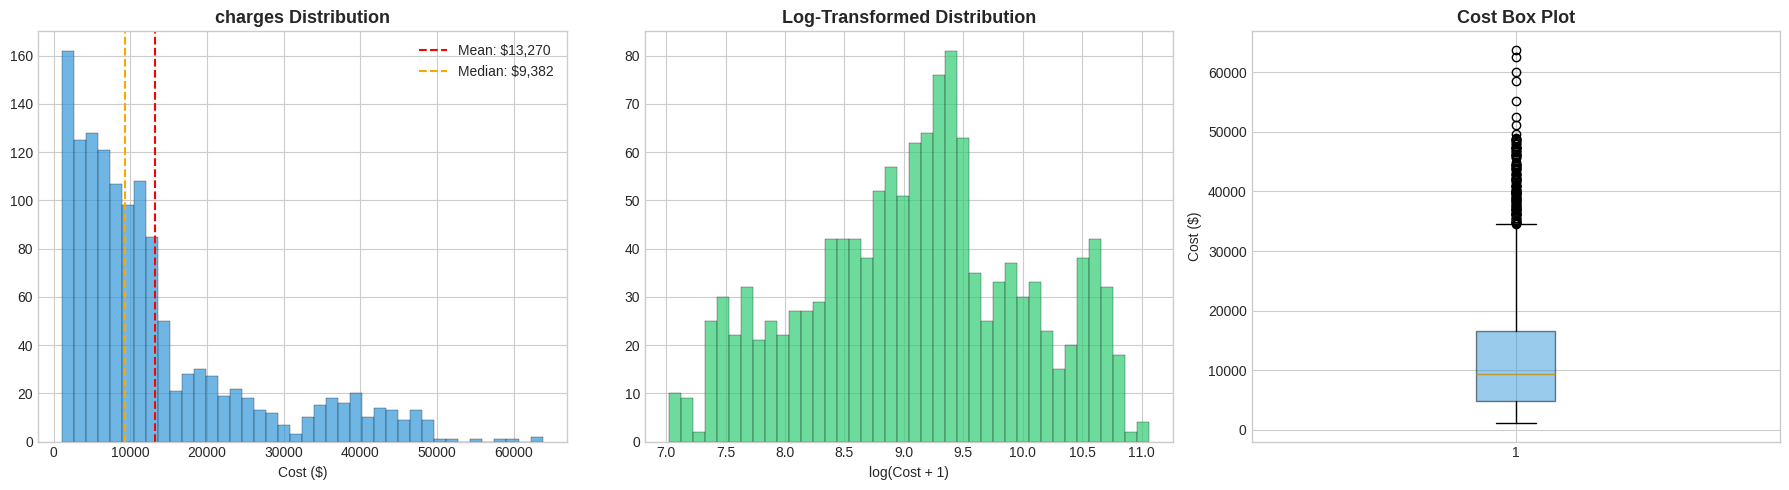

AU context: Average PHI premium ~$2,300/person/year (APRA 2022-23).
Total health expenditure $220B (2021-22), ~10% of GDP (AIHW).
Community rating means premiums can't vary by health status — but cost prediction still matters for pool management.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df[target_col], bins=40, color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[0].set_title(f'{target_col} Distribution', fontsize=13, fontweight='bold')
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: ${df[target_col].mean():,.0f}')
axes[0].axvline(df[target_col].median(), color='orange', linestyle='--', label=f'Median: ${df[target_col].median():,.0f}')
axes[0].legend(); axes[0].set_xlabel('Cost ($)')

axes[1].hist(np.log1p(df[target_col]), bins=40, color='#2ecc71', edgecolor='black', linewidth=0.3, alpha=0.7)
axes[1].set_title('Log-Transformed Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Cost + 1)')

axes[2].boxplot(df[target_col], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.5))
axes[2].set_title('Cost Box Plot', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Cost ($)')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Average PHI premium ~$2,300/person/year (APRA 2022-23).")
print("Total health expenditure $220B (2021-22), ~10% of GDP (AIHW).")
print("Community rating means premiums can't vary by health status — but cost prediction still matters for pool management.")


## 3. Exploratory Data Analysis

Key questions for health economics:
- How strongly does smoking affect medical costs?
- What is the age-cost relationship (linear vs exponential)?
- Does BMI have a threshold effect on costs?
- How does family size (children) affect total charges?


Numeric features (3): ['age', 'bmi', 'children']


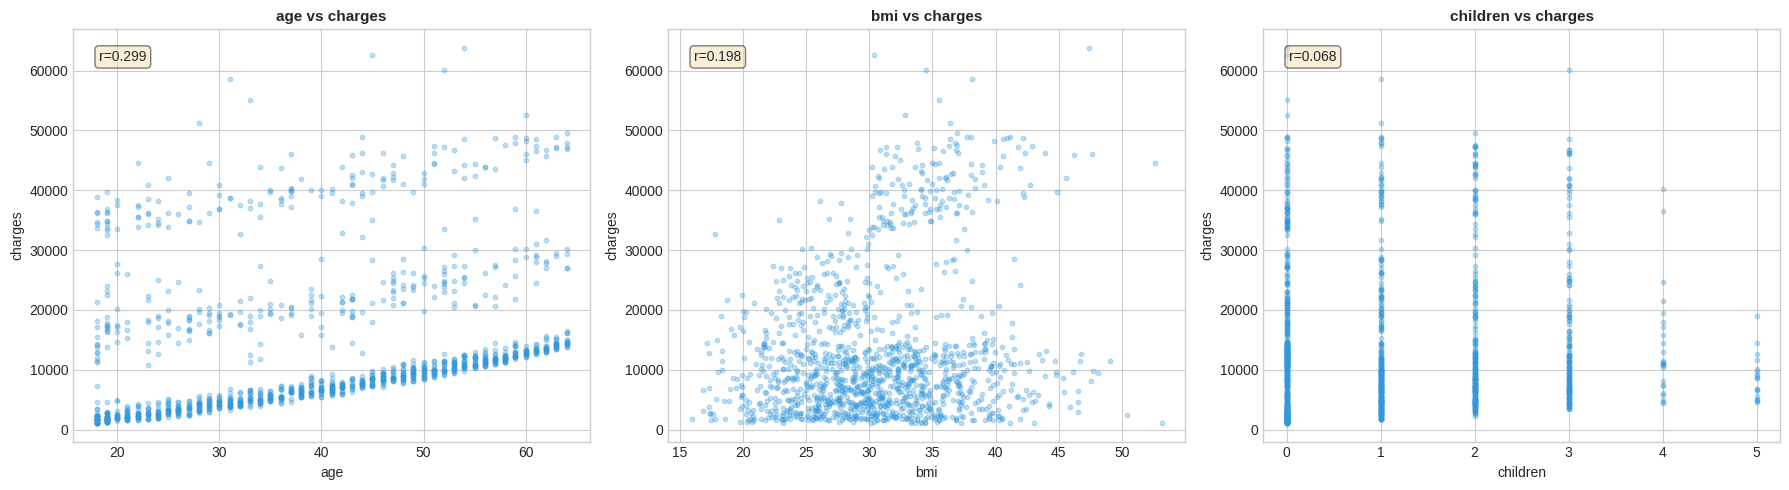

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

if len(numeric_cols) > 0:
    fig, axes = plt.subplots(1, min(len(numeric_cols), 3), figsize=(6 * min(len(numeric_cols), 3), 5))
    if not isinstance(axes, np.ndarray): axes = [axes]
    for i, col in enumerate(numeric_cols[:3]):
        axes[i].scatter(df[col], df[target_col], alpha=0.3, s=10, color='#3498db')
        axes[i].set_xlabel(col); axes[i].set_ylabel(target_col)
        axes[i].set_title(f'{col} vs {target_col}', fontsize=11, fontweight='bold')
        corr_val = df[[col, target_col]].corr().iloc[0, 1]
        axes[i].text(0.05, 0.95, f'r={corr_val:.3f}', transform=axes[i].transAxes, fontsize=10,
                     va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout(); plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['sex', 'smoker', 'region']


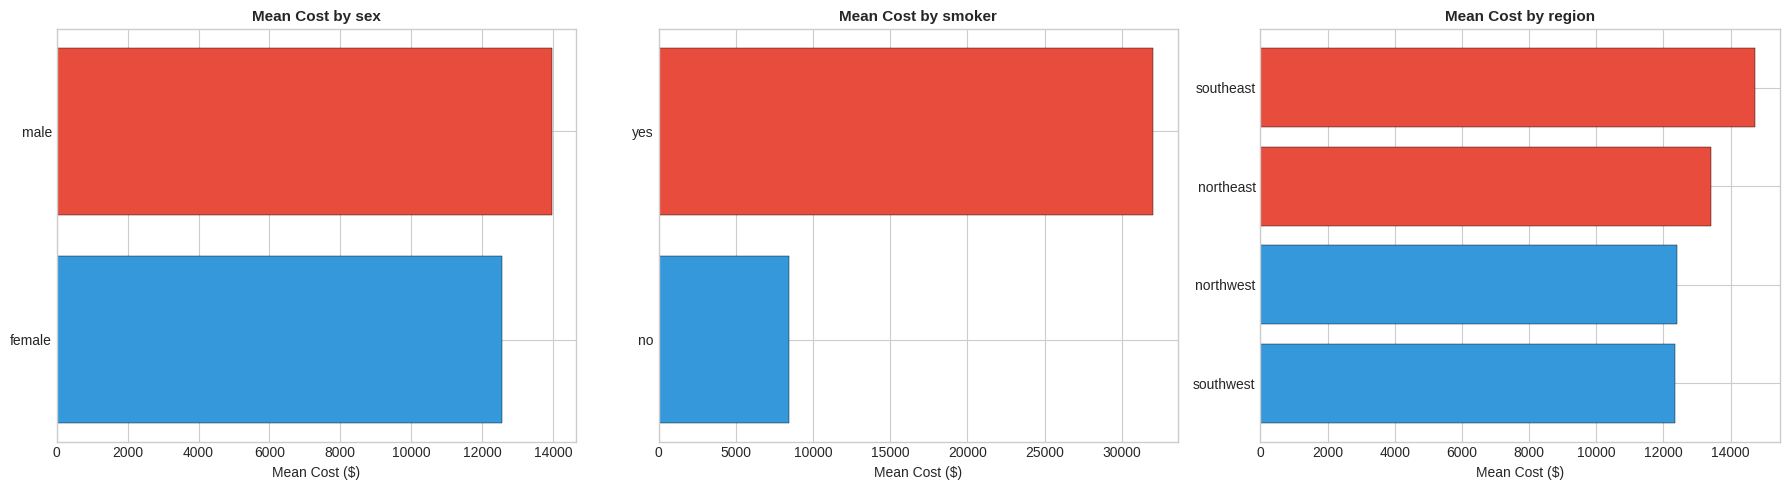

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    fig, axes = plt.subplots(1, min(len(cat_cols), 3), figsize=(6 * min(len(cat_cols), 3), 5))
    if not isinstance(axes, np.ndarray): axes = [axes]
    for i, col in enumerate(cat_cols[:3]):
        means = df.groupby(col)[target_col].mean().sort_values()
        clrs = ['#e74c3c' if v > df[target_col].mean() else '#3498db' for v in means.values]
        axes[i].barh(means.index.astype(str), means.values, color=clrs, edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'Mean Cost by {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Mean Cost ($)')
    plt.tight_layout(); plt.savefig('categorical_costs.png', dpi=150, bbox_inches='tight'); plt.show()


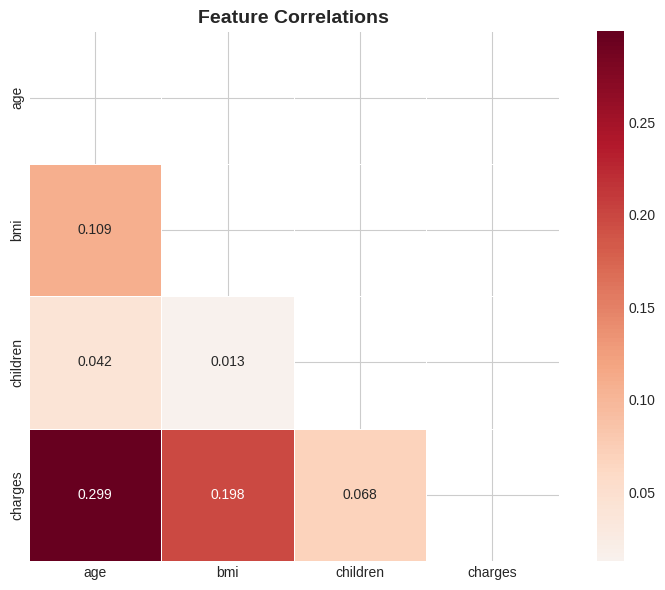

In [8]:
all_numeric = numeric_cols + [target_col]
if len(all_numeric) > 1:
    corr = df[all_numeric].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes -> {list(le.classes_)}")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Log transform target if skewed
use_log = False
if abs(pd.Series(y).skew()) > 1 and (y > 0).all():
    y = np.log1p(y)
    use_log = True
    print(f"\nApplied log1p transform to target (skew was {df[target_col].skew():.2f})")

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

# Feature engineering
composites_added = []

# BMI risk categories
if 'bmi' in X.columns:
    X['bmi_obese'] = (X['bmi'] >= 30).astype(int)
    X['bmi_overweight'] = ((X['bmi'] >= 25) & (X['bmi'] < 30)).astype(int)
    composites_added.extend(['bmi_obese', 'bmi_overweight'])
    print("Created 'bmi_obese' and 'bmi_overweight'")

# Age brackets
if 'age' in X.columns:
    X['age_senior'] = (X['age'] >= 60).astype(int)
    X['age_squared'] = X['age'] ** 2
    composites_added.extend(['age_senior', 'age_squared'])
    print("Created 'age_senior' and 'age_squared'")

# Smoker-BMI interaction (known high-cost combination)
smoker_cols = [c for c in X.columns if c.lower() in ['smoker', 'smoking']]
if smoker_cols and 'bmi' in X.columns:
    X['smoker_bmi'] = X[smoker_cols[0]] * X['bmi']
    composites_added.append('smoker_bmi')
    print("Created 'smoker_bmi' interaction")

# Smoker-age interaction
if smoker_cols and 'age' in X.columns:
    X['smoker_age'] = X[smoker_cols[0]] * X['age']
    composites_added.append('smoker_age')
    print("Created 'smoker_age' interaction")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final: {X.shape}")


  Encoded 'sex': 2 classes -> ['female', 'male']
  Encoded 'smoker': 2 classes -> ['no', 'yes']
  Encoded 'region': 4 classes -> ['northeast', 'northwest', 'southeast', 'southwest']

Applied log1p transform to target (skew was 1.52)
Created 'bmi_obese' and 'bmi_overweight'
Created 'age_senior' and 'age_squared'
Created 'smoker_bmi' interaction
Created 'smoker_age' interaction

Engineered: 6
Final: (1338, 12)


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBRegressor
    print("XGBoost loaded")
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
    print("LightGBM loaded")
except ImportError:
    LGBMRegressor = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
if LGBMRegressor is not None:
    models['LightGBM'] = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1,
                                        force_col_wise=True)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_rmse, fold_mae, fold_r2 = [], [], []
    fold_preds = np.zeros(len(y))
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_arr[train_idx], y[train_idx])
        y_pred = model_clone.predict(X_arr[val_idx])
        fold_preds[val_idx] = y_pred
        rmse = np.sqrt(mean_squared_error(y[val_idx], y_pred))
        mae = mean_absolute_error(y[val_idx], y_pred)
        r2 = r2_score(y[val_idx], y_pred)
        fold_rmse.append(rmse); fold_mae.append(mae); fold_r2.append(r2)
        print(f"  Fold {fold_idx+1}: RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {'rmse_mean': np.mean(fold_rmse), 'mae_mean': np.mean(fold_mae),
        'r2_mean': np.mean(fold_r2), 'r2_std': np.std(fold_r2),
        'time': elapsed, 'oof_preds': fold_preds}
    print(f"  -- RMSE: {np.mean(fold_rmse):.4f}  MAE: {np.mean(fold_mae):.4f}  R2: {np.mean(fold_r2):.4f}  Time: {elapsed:.2f}s")



Training: Ridge
  Fold 1: RMSE=0.3856  MAE=0.2085  R2=0.8243
  Fold 2: RMSE=0.3564  MAE=0.2075  R2=0.8458
  Fold 3: RMSE=0.4125  MAE=0.2292  R2=0.8025
  -- RMSE: 0.3848  MAE: 0.2151  R2: 0.8242  Time: 0.03s

Training: Random Forest
  Fold 1: RMSE=0.4034  MAE=0.2034  R2=0.8077
  Fold 2: RMSE=0.3714  MAE=0.1907  R2=0.8326
  Fold 3: RMSE=0.4265  MAE=0.2163  R2=0.7888
  -- RMSE: 0.4004  MAE: 0.2034  R2: 0.8097  Time: 0.69s

Training: XGBoost
  Fold 1: RMSE=0.4453  MAE=0.2369  R2=0.7657
  Fold 2: RMSE=0.4140  MAE=0.2263  R2=0.7919
  Fold 3: RMSE=0.4592  MAE=0.2489  R2=0.7552
  -- RMSE: 0.4395  MAE: 0.2373  R2: 0.7709  Time: 0.32s

Training: LightGBM
  Fold 1: RMSE=0.4094  MAE=0.2242  R2=0.8019
  Fold 2: RMSE=0.3794  MAE=0.2111  R2=0.8252
  Fold 3: RMSE=0.4303  MAE=0.2407  R2=0.7850
  -- RMSE: 0.4064  MAE: 0.2253  R2: 0.8040  Time: 0.28s


## 6. Model Comparison & Selection

In [12]:
summary_rows = [{'Model': mn, 'RMSE': f"{res['rmse_mean']:.4f}",
    'MAE': f"{res['mae_mean']:.4f}",
    'R2': f"{res['r2_mean']:.4f} +/- {res['r2_std']:.4f}",
    'Time': f"{res['time']:.2f}s", 'sort_val': res['r2_mean']}
    for mn, res in results.items()]
summary_df = pd.DataFrame(summary_rows).sort_values('sort_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 80)
print(summary_df[['Model', 'RMSE', 'MAE', 'R2', 'Time']].to_string(index=False))
print("=" * 80)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
        Model   RMSE    MAE                R2  Time
        Ridge 0.3848 0.2151 0.8242 +/- 0.0177 0.03s
Random Forest 0.4004 0.2034 0.8097 +/- 0.0179 0.69s
     LightGBM 0.4064 0.2253 0.8040 +/- 0.0165 0.28s
      XGBoost 0.4395 0.2373 0.7709 +/- 0.0154 0.32s

Best model: Ridge


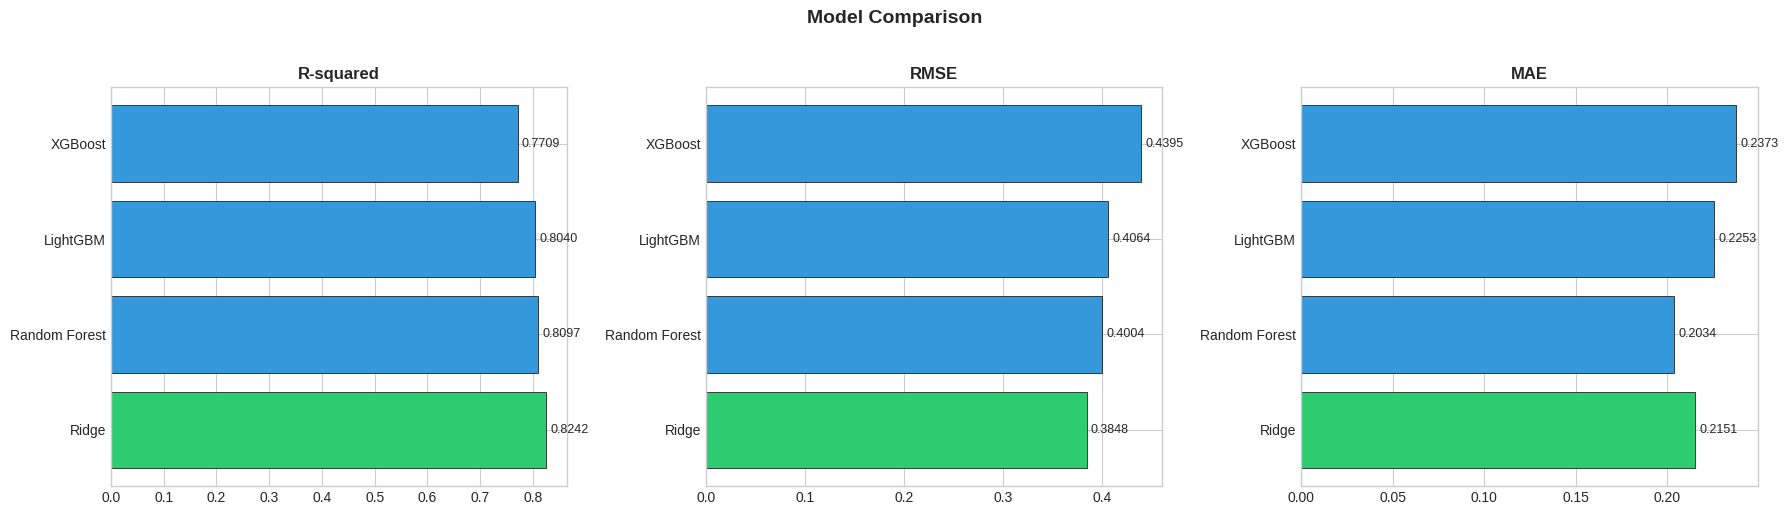

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors_bar = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title, higher_better in zip(axes,
    ['r2_mean', 'rmse_mean', 'mae_mean'], ['R-squared', 'RMSE', 'MAE'], [True, False, False]):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors_bar, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i, v in enumerate(vals):
        ax.text(v + max(vals)*0.01, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Residual Analysis

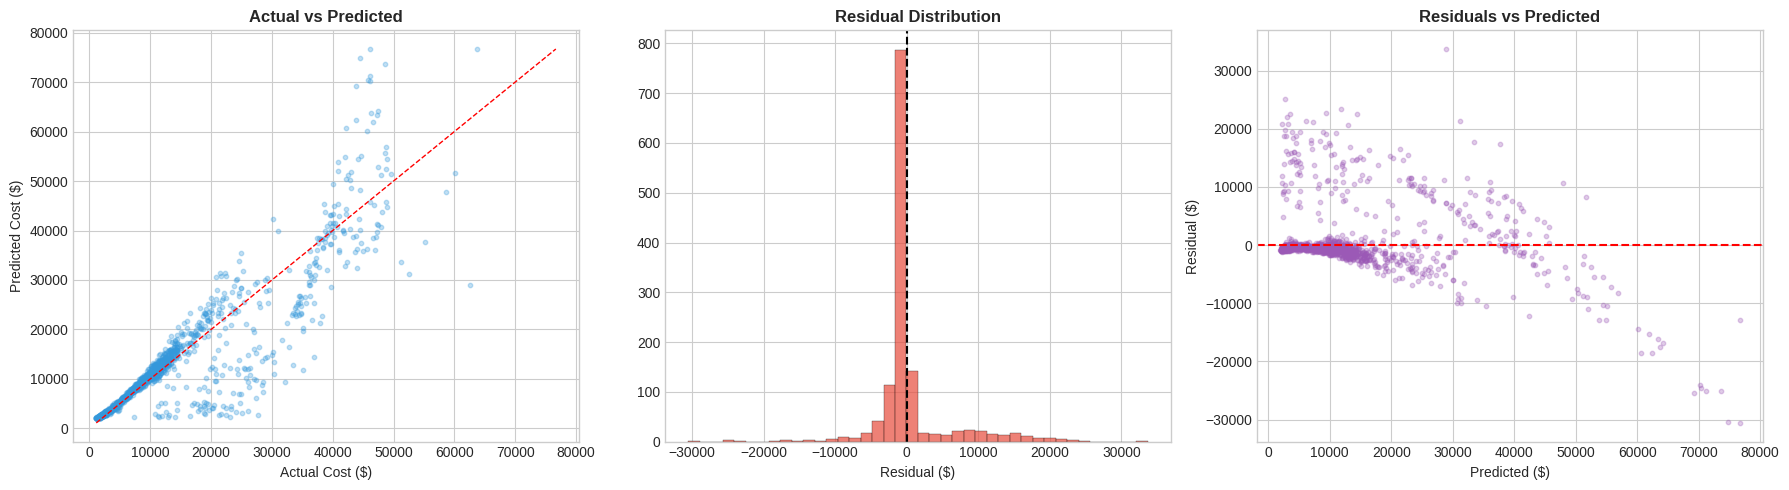


Residual stats (original scale):
  Mean: $468
  Std:  $5,545
  MAPE: 18.9%


In [14]:
best_preds = results[best_model_name]['oof_preds']
if use_log:
    y_plot = np.expm1(y); pred_plot = np.expm1(best_preds)
else:
    y_plot = y; pred_plot = best_preds
residuals = y_plot - pred_plot

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_plot, pred_plot, alpha=0.3, s=10, color='#3498db')
lims = [min(y_plot.min(), pred_plot.min()), max(y_plot.max(), pred_plot.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual Cost ($)'); axes[0].set_ylabel('Predicted Cost ($)')

axes[1].hist(residuals, bins=40, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual ($)')

axes[2].scatter(pred_plot, residuals, alpha=0.3, s=10, color='#9b59b6')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')
axes[2].set_xlabel('Predicted ($)'); axes[2].set_ylabel('Residual ($)')
plt.tight_layout(); plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"\nResidual stats (original scale):")
print(f"  Mean: ${np.mean(residuals):,.0f}")
print(f"  Std:  ${np.std(residuals):,.0f}")
print(f"  MAPE: {np.mean(np.abs(residuals) / (y_plot + 1)) * 100:.1f}%")


## 8. Feature Importance & Policy Insights

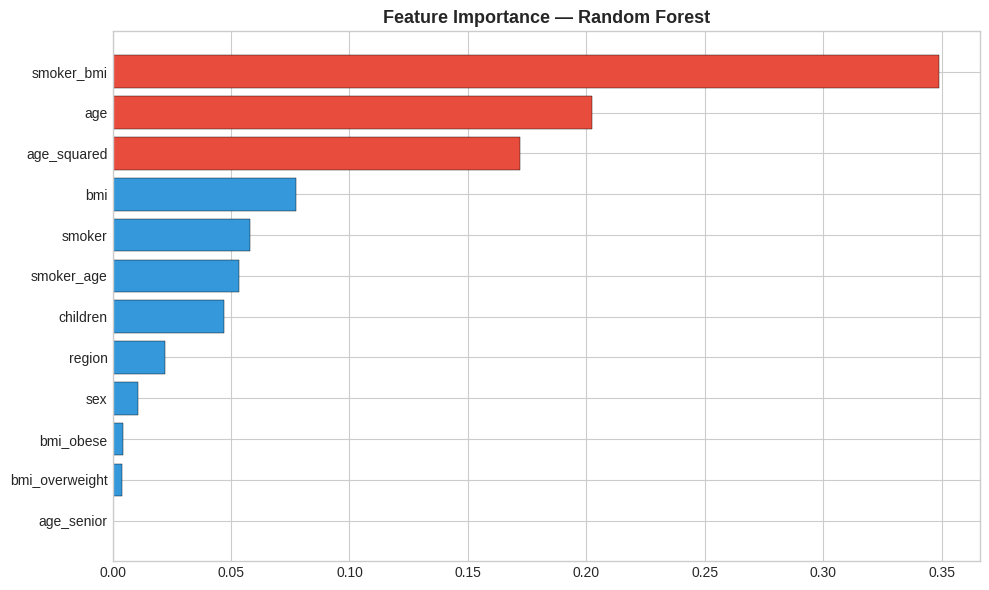

TOP 5 COST DRIVERS
  smoker_bmi                 0.3488
  age                        0.2024
  age_squared                0.1720
  bmi                        0.0775
  smoker                     0.0579

Policy insight: Smoking is overwhelmingly the largest modifiable cost driver.
BMI and age are strong predictors — supports preventive health investment.
Smoker-BMI interaction shows compounding effect of combined risk factors.


In [15]:
tree_models = {k: v for k, v in models.items() if k != 'Ridge'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['r2_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, len(feat_imp) * 0.5)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 COST DRIVERS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nPolicy insight: Smoking is overwhelmingly the largest modifiable cost driver.")
    print("BMI and age are strong predictors — supports preventive health investment.")
    print("Smoker-BMI interaction shows compounding effect of combined risk factors.")


## 9. Deployment Readiness & Production Considerations

In [16]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  RMSE:                 {best_res['rmse_mean']:.4f}")
print(f"  MAE:                  {best_res['mae_mean']:.4f}")
print(f"  R-squared:            {best_res['r2_mean']:.4f}")
if use_log:
    print(f"  (log-transformed target)")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold KFold")
print("=" * 60)
checks = {
    'R2 > 0.80': best_res['r2_mean'] > 0.80,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Residual analysis done': True,
    'Feature importance available': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Ridge
  RMSE:                 0.3848
  MAE:                  0.2151
  R-squared:            0.8242
  (log-transformed target)
  Training time:        0.0s
  Feature count:        12
  Dataset rows:         1,338
  CV strategy:          3-fold KFold

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] R2 > 0.80
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Residual analysis done
  [pass] Feature importance available
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [17]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: PHI claims databases, APRA reporting data, ABS health surveys
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (demographics, risk factors, claims history)
   Schedule: Quarterly premium cycle + annual actuarial review

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring for actuarial modelling
   Output: Expected cost + confidence interval + cost drivers
   Dashboard: Power BI (cost distribution by risk segment)

3. INTEGRATION POINTS
   APRA: Premium adequacy reporting, risk equalisation
   Actuarial: Individual expected cost for pool management
   Preventive health: ROI modelling for wellness programs
   Medicare: MBS/PBS utilisation trend integration
   PHIO: Premium fairness monitoring

4. GOVERNANCE (Community Rating)
   Community rating: AU law prohibits risk-rated premiums — model for pool management ONLY
   Lifetime Health Cover: Age-based loading is the only permitted variation
   Anti-discrimination: Cannot use for individual premium discrimination
   Privacy: Health data under Privacy Act 1988 + My Health Records Act
   APRA: Actuarial standards compliance (PS 310)

5. MONITORING & RETRAINING
   Drift: PSI on demographic/health features annually
   Performance: MAE against actual claims outcomes annually
   Retraining: Annual with latest claims data
   Healthcare inflation: Adjust for CPI health component
   Policy changes: Recalibrate for MBS/PBS fee schedule changes

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: PHI claims databases, APRA reporting data, ABS health surveys
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (demographics, risk factors, claims history)
   Schedule: Quarterly premium cycle + annual actuarial review

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Batch scoring for actuarial modelling
   Output: Expected cost + confidence interval + cost drivers
   Dashboard: Power BI (cost distribution by risk segment)

3. INTEGRATION POINTS
   APRA: Premium adequacy reporting, risk equalisation
   Actuarial: Individual expected cost for pool management
   Preventive health: ROI modelling for wellness programs
   Medicare: MBS/PBS utilisation trend integration
   PHIO: Premium fairness monitoring

4. GOVERNANCE (Community Rating)
   Community rating: AU law prohibits risk-rated premiums — model for pool management ONLY
   Lifetime Health Cover